<a href="https://colab.research.google.com/github/dhanashriekke60-lgtm/Python-Basic-Projects/blob/main/Assignment_No_17.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}" with length {len(uploaded[fn])} bytes')

Saving heart.csv to heart.csv
User uploaded file "heart.csv" with length 36838 bytes


In [6]:
# Q1: i)Load the Heart Dataset
filepath = '/content/heart.csv'
df = pd.read_csv(filepath)
print("Insurance Dataset:")
df

Insurance Dataset:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
...,...,...,...,...,...,...,...,...,...,...,...,...
913,45,M,TA,110,264,0,Normal,132,N,1.2,Flat,1
914,68,M,ASY,144,193,1,Normal,141,N,3.4,Flat,1
915,57,M,ASY,130,131,0,Normal,115,Y,1.2,Flat,1
916,57,F,ATA,130,236,0,LVH,174,N,0.0,Flat,1


In [9]:
# ii) display First 10 rows
print("First 10 Rows:")
df.head(10)


First 10 Rows:


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [10]:
# iii) Display Shape
print("Shape of Dataset:")
df.shape

Shape of Dataset:


(918, 12)

In [12]:
# iv) Display Dataset Information
print("Dataset Information:")
df.info()


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [13]:
# Q2: Check for missing values.
print("Missing Values in Each Column:")
print(df.isnull().sum())

Missing Values in Each Column:
Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64


In [16]:
# Q3: Check for duplicate rows and remove them.

print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("\nNew Shape of Dataset:")
print(df.shape)

Duplicate Rows: 0

New Shape of Dataset:
(918, 12)


In [17]:
# Q4. Identify unrealistic/invalid values.
# Count Cholesterol = 0
chol_zero = (df["Cholesterol"] == 0).sum()

# Count RestingBP = 0
bp_zero = (df["RestingBP"] == 0).sum()

print("Rows with Cholesterol = 0 :", chol_zero)
print("Rows with RestingBP = 0 :", bp_zero)

Rows with Cholesterol = 0 : 172
Rows with RestingBP = 0 : 1


In [20]:
# Q5: Clean the invalid values.
# before cleaning
print("Before Cleaning")
print(df[["Cholesterol","RestingBP"]].describe())

# Mean excluding zero
chol_mean = df[df["Cholesterol"] != 0]["Cholesterol"].mean()
bp_mean = df[df["RestingBP"] != 0]["RestingBP"].mean()

# Replace zero values
df["Cholesterol"] = df["Cholesterol"].replace(0, chol_mean)
df["RestingBP"] = df["RestingBP"].replace(0, bp_mean)

# Round to 2 decimal places
df["Cholesterol"] = df["Cholesterol"].round(2)
df["RestingBP"] = df["RestingBP"].round(2)

# after cleaning
print("\nAfter Cleaning")
print(df[["Cholesterol","RestingBP"]].describe())

Before Cleaning
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000

After Cleaning
       Cholesterol   RestingBP
count   918.000000  918.000000
mean    244.636253  132.540893
std      53.318029   17.989932
min      85.000000   80.000000
25%     214.000000  120.000000
50%     244.640000  130.000000
75%     267.000000  140.000000
max     603.000000  200.000000


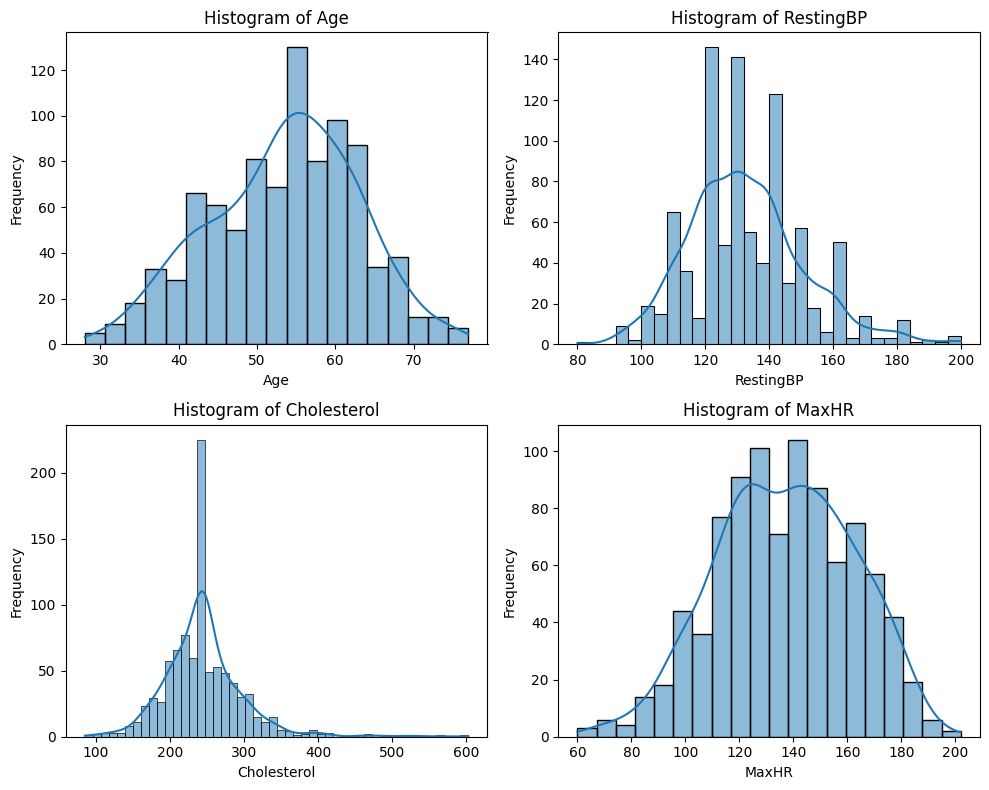

In [22]:
# Q6:Create a function to plot histograms (2×2 layout).
import matplotlib.pyplot as plt
import seaborn as sns

# Function to plot histograms
def plot_histograms(data):

    columns = ["Age", "RestingBP", "Cholesterol", "MaxHR"]

    plt.figure(figsize=(10,8))

    for i, col in enumerate(columns, 1):
        plt.subplot(2,2,i)
        sns.histplot(data[col], kde=True)
        plt.title(f"Histogram of {col}")
        plt.xlabel(col)
        plt.ylabel("Frequency")

    plt.tight_layout()
    plt.show()

# Call the function
plot_histograms(df)

In [23]:
# Q7:Identify and print numerical columns and categorical columns separately.

# Identify numerical columns
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns

print("Numerical Columns:")
print(numerical_columns.tolist())

# Identify categorical columns
categorical_columns = df.select_dtypes(include=['object']).columns

print("\nCategorical Columns:")
print(categorical_columns.tolist())

Numerical Columns:
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak', 'HeartDisease']

Categorical Columns:
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina', 'ST_Slope']


In [26]:
# Q8:Perform One-Hot Encoding on all categorical columns.

# One-Hot Encoding
df_encoded = pd.get_dummies(df)

# Display shape
print("Shape of Encoded DataFrame:")
print(df_encoded.shape)

# Display first 5 rows
print("\nFirst 5 Rows:")
print(df_encoded.head())

Shape of Encoded DataFrame:
(918, 21)

First 5 Rows:
   Age  RestingBP  Cholesterol  FastingBS  MaxHR  Oldpeak  HeartDisease  \
0   40      140.0        289.0          0    172      0.0             0   
1   49      160.0        180.0          0    156      1.0             1   
2   37      130.0        283.0          0     98      0.0             0   
3   48      138.0        214.0          0    108      1.5             1   
4   54      150.0        195.0          0    122      0.0             0   

   Sex_F  Sex_M  ChestPainType_ASY  ...  ChestPainType_NAP  ChestPainType_TA  \
0  False   True              False  ...              False             False   
1   True  False              False  ...               True             False   
2  False   True              False  ...              False             False   
3   True  False               True  ...              False             False   
4  False   True              False  ...               True             False   

   RestingECG_L

In [28]:
# Q9. After cleaning and encoding.

# Final shape
print("Final Shape of Encoded DataFrame:")
print(df_encoded.shape)

# List of column names
print("\nColumn Names:")
print(df_encoded.columns)

Final Shape of Encoded DataFrame:
(918, 21)

Column Names:
Index(['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak',
       'HeartDisease', 'Sex_F', 'Sex_M', 'ChestPainType_ASY',
       'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA',
       'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST',
       'ExerciseAngina_N', 'ExerciseAngina_Y', 'ST_Slope_Down',
       'ST_Slope_Flat', 'ST_Slope_Up'],
      dtype='object')


In [29]:
# Q10:Summary

# 1.
# Cholesterol = 0 and RestingBP = 0 were found.
# These values were replaced with the mean of the respective columns (excluding zeros).

# 2.
# Zero values are unrealistic and can affect the accuracy of data analysis.
# Replacing them improves data quality.

# 3.
# One-Hot Encoding converts categorical data into numerical format.
# This makes the dataset suitable for machine learning algorithms.

# 4.
# Duplicate rows were removed.
# Missing values were checked.
# The cleaned dataset is ready for analysis, visualization, and machine learning.